# Min Max Normalization

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
data = r"wine_data.csv"
df = pd.read_csv(data,usecols=[0,1,2])
df.columns = ['Class label','Alcohol','Malic acid']

In [15]:
df

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

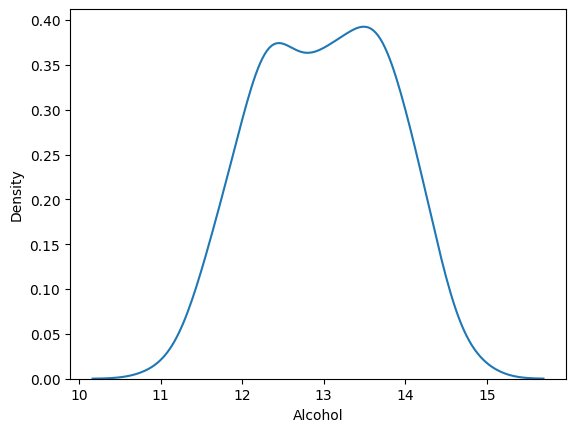

In [17]:
sns.kdeplot(df.Alcohol)

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

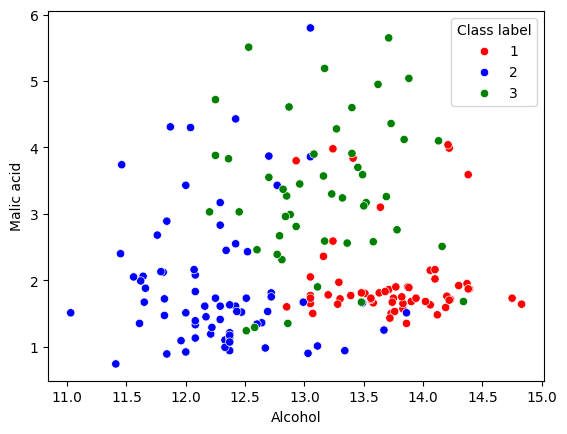

In [23]:
palatte = {1:"red",2:"blue",3:"green"}
sns.scatterplot(data=df,x="Alcohol",y="Malic acid",hue="Class label",palette=palatte)

In [25]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop("Class label",axis=1),df["Class label"],test_size=.3,random_state=42)

X_train.shape,X_test.shape

((124, 2), (54, 2))

In [27]:
from sklearn.preprocessing  import MinMaxScaler
scaler = MinMaxScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [29]:
X_train_scaled = pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [32]:
X_train_scaled.describe()

,Alcohol,Malic acid
count,124.000000,124.000000
mean,0.508765,0.308143
std,0.221444,0.224504
min,0.000000,0.000000
25%,0.331579,0.152749
50%,0.503947,0.205703
75%,0.701316,0.464358
max,1.000000,1.000000


In [34]:
X_test_scaled.describe()

,Alcohol,Malic acid
count,54.000000,54.000000
mean,0.541131,0.263408
std,0.194622,0.233436
min,0.100000,-0.030550
25%,0.365789,0.095723
50%,0.569737,0.171079
75%,0.683553,0.388493
max,0.871053,0.940937


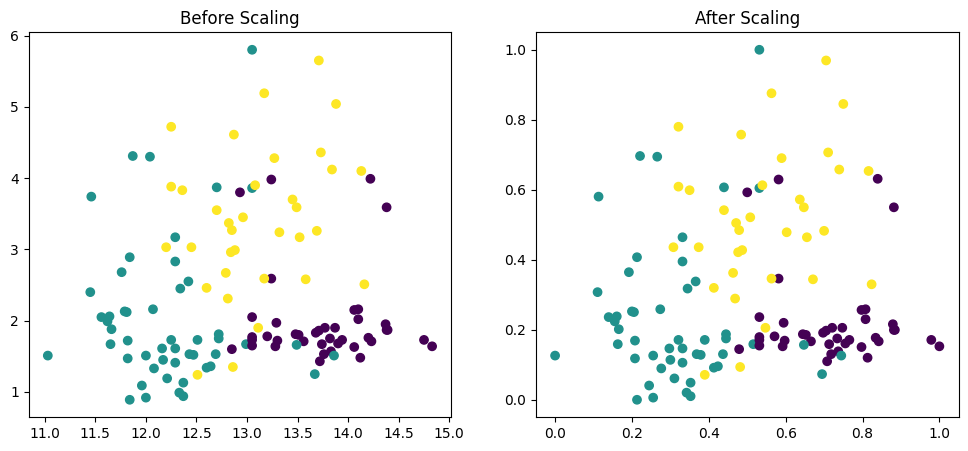

In [38]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train["Alcohol"],X_train["Malic acid"],c=y_train)
ax1.set_title("Before Scaling")

ax2.scatter(X_train_scaled["Alcohol"],X_train_scaled["Malic acid"],c=y_train)
ax2.set_title("After Scaling")

plt.show()

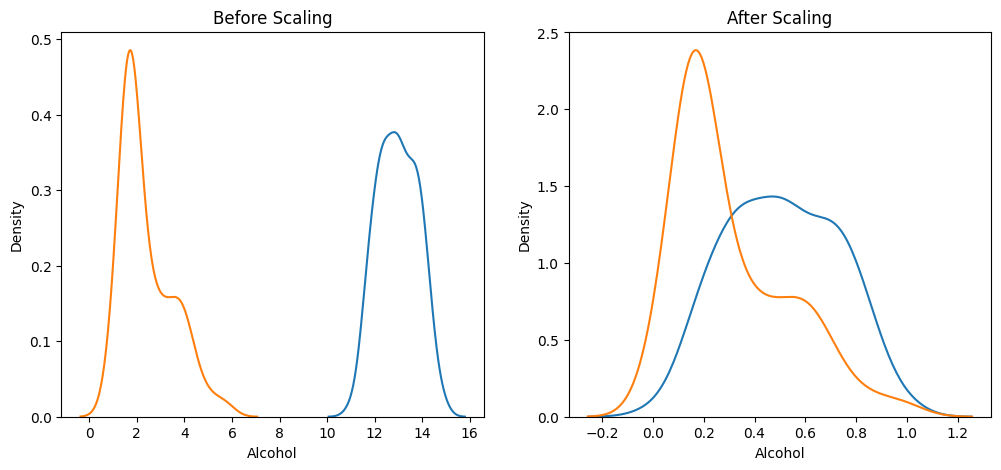

In [48]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title("Before Scaling")
sns.kdeplot(X_train["Alcohol"],ax=ax1)
sns.kdeplot(X_train["Malic acid"],ax=ax1)

ax2.set_title("After Scaling")
sns.kdeplot(X_train_scaled["Alcohol"],ax=ax2)
sns.kdeplot(X_train_scaled["Malic acid"],ax=ax2)

plt.show()